# Disorder

Everything else in matverse assumes a structure is ordered: this atom is here,
that one is there. A large fraction of real materials are not.

A solid solution, a doped semiconductor, a high-entropy alloy and a cathode
part-way through charging all have sites that are **fractionally occupied** —
and a first-principles code cannot take one as input. It needs a specific
arrangement of specific atoms.

Bridging that gap is a bigger problem than it looks. A disordered cell stands
for an *ensemble*, and any single ordered cell you pick is one sample from it.
Which sample you pick changes the answer, and choosing wrongly is one of the
easier ways to compute something confidently meaningless.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.18   🧮 Functions: 155   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Three cases spanning the problem: a binary solid solution, a five-component
equiatomic alloy of the kind called *high-entropy*, and an ordered metal for
contrast.

In [2]:
from pymatgen.core import Lattice, Structure


def mixed(occupancies, a=3.7):
    """An fcc cell whose every site is shared between species."""
    return Structure(Lattice.cubic(a), [dict(occupancies)] * 4,
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


md = mv.data.from_structures([
    mixed({"Cu": 0.5, "Au": 0.5}, a=3.8),
    mixed({"Cu": 0.2, "Ni": 0.2, "Co": 0.2, "Fe": 0.2, "Mn": 0.2}),
    mv.structures(mv.datasets.metals(["Cu"]))[0],
])
mv.pp.describe(md)

md.obs[["formula", "nsites", "density"]].round(3)

,formula,nsites,density
0,CuAu,4,15.767
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,4,7.657
2,Cu,4,8.935


Note that `mv.pp.describe` reports a formula for all three — a disordered cell
is a perfectly good structure, it just is not one you can hand to VASP.

## How disordered, and where

In [3]:
mv.disorder.describe(md, temperature=1500.0)

md.obs[["formula", "is_ordered", "n_disordered_sites", "max_site_disorder",
        "configurational_entropy", "entropy_term_300K"]].round(5)

,formula,is_ordered,n_disordered_sites,max_site_disorder,configurational_entropy,entropy_term_300K
0,CuAu,False,4,0.5,0.00006,-0.08960
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,False,4,0.8,0.00014,-0.20804
2,Cu,True,0,0.0,0.00000,-0.00000


`max_site_disorder` is how far the worst site is from having a single owner:
0.5 for an even two-way split, 0.8 for an even five-way split, 0 for an ordered
cell.

## The entropy a zero-temperature hull leaves out

`configurational_entropy` is the ideal mixing entropy per atom. For an
equiatomic mixture of *m* species it has a closed form, `k_B ln m`, which is
worth checking rather than trusting:

In [4]:
predicted = mv.disorder.KB_EV * np.log([2, 5, 1])
pd.DataFrame({
    "formula": md.obs["formula"],
    "computed": md.obs["configurational_entropy"].to_numpy(dtype=float),
    "k_B ln(m)": predicted,
}).round(8)

,formula,computed,k_B ln(m)
0,CuAu,0.000060,0.000060
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,0.000139,0.000139
2,Cu,0.000000,0.000000


Exact. And the consequence is the interesting part.

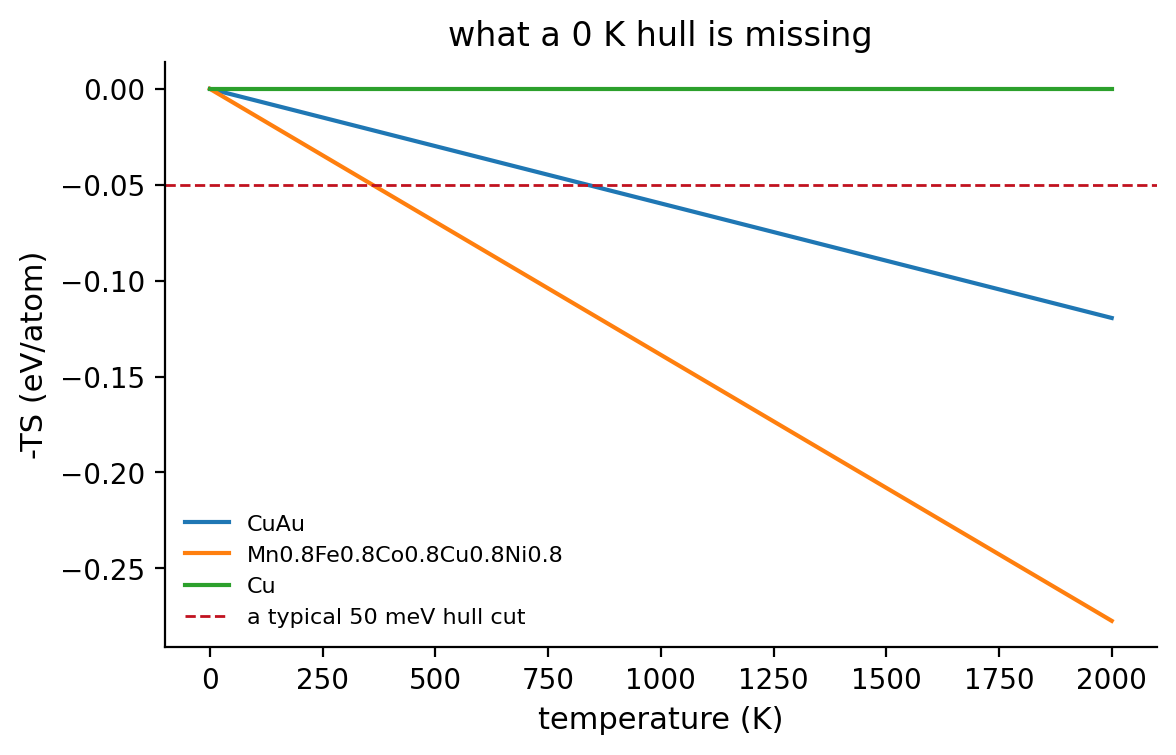

In [5]:
import matplotlib.pyplot as plt

temperatures = np.linspace(0, 2000, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for formula, entropy in zip(md.obs["formula"],
                            md.obs["configurational_entropy"]):
    ax.plot(temperatures, -temperatures * entropy, label=formula)
ax.axhline(-0.05, linestyle="--", color="#c1121f", linewidth=1.0,
           label="a typical 50 meV hull cut")
ax.set_xlabel("temperature (K)")
ax.set_ylabel("-TS (eV/atom)")
ax.set_title("what a 0 K hull is missing")
ax.legend(fontsize=8)

At room temperature the entropy term is tens of meV and usually ignorable. At a
synthesis temperature of 1500 K the five-component alloy gets **−0.21 eV/atom**
— four times the 50 meV that a screen typically calls "close to the hull".

That is the whole argument for high-entropy alloys: a material can sit well
above the convex hull at 0 K and still be the phase that forms, for no reason
other than that there are a lot of ways to arrange it.

```{warning}
This is an **upper bound**. Real mixing is never ideal, and short-range order —
which is the norm rather than the exception in concentrated alloys — reduces
the entropy below `k_B ln m`. Treating the ideal value as the true one
overstabilises exactly the materials it is used to justify.
```

## Making something a DFT code can read

`mv.disorder.orderings` enumerates specific arrangements and returns them as an
ordinary materials object — the same shape as `mv.mag.orderings` and
`mv.pp.defects`, because it is the same move: enumerate the configurations,
compute them all, let the object record which won.

In [6]:
ordered = mv.disorder.orderings(md, n=3)
mv.pp.describe(ordered)

ordered.obs[["parent", "ordering_index", "formula", "nsites",
             "ewald_energy"]]

,parent,ordering_index,formula,nsites,ewald_energy
0,0,0,CuAu,4,0.0
1,0,1,CuAu,4,0.0
2,0,2,CuAu,4,0.0
3,1,0,MnFeCoNi,4,0.0
4,1,1,MnFeCoNi,4,0.0
5,1,2,MnFeCoNi,4,0.0
6,2,0,Cu,4,NaN


In [7]:
all(s.is_ordered for s in mv.structures(ordered))

True

Every cell is now ordered, and the compositions survived: Cu₀.₅Au₀.₅ became
CuAu, not something else.

The already-ordered copper passed through as a single row rather than being
dropped, so every input material is still represented and nothing needs
re-joining by hand.

### The ranking is arbitrary here, and it says so

In [8]:
ordered.uns["orderings"]

{'source': 'input',
 'n_requested': 3,
 'use_oxidation': False,
 'n_failed': 0,
 'errors': [],
 'note': 'the best n by Ewald energy, not every arrangement; the count of distinct arrangements grows combinatorially',
 'ranking': 'no oxidation states, so every Ewald energy is zero and the order is arbitrary. Honest for an alloy; pass use_oxidation=True for an oxide, where electrostatics is what decides.'}

Arrangements are ranked by **Ewald energy**, which needs oxidation states.
Without them every arrangement scores zero and the order is arbitrary — which
is honest for a metallic alloy, where electrostatics is not what decides
anything, and would be wrong for an oxide. Pass `use_oxidation=True` there.

The object records that rather than presenting an arbitrary order as a result.

```{note}
`n=3` returned three arrangements. There are far more: the count of distinct
arrangements grows combinatorially with cell size, and `uns['orderings']` says
this is a subset. A screen over "the orderings" of a concentrated alloy is
always a screen over a sample.
```

## When ordering is the wrong tool

Here is the trap. `orderings` ranks arrangements and gives you the best ones —
that is, the **ordered ground state**. A solid solution is the opposite of an
ordered ground state.

If you want a cell that behaves like a random alloy, you want a *special
quasirandom structure*: the small cell whose correlation functions best match a
genuinely random one.

In [9]:
try:
    mv.disorder.sqs(md, scaling=1, search_time=0.05)
except ImportError as exc:
    print(f"ImportError: {exc}")

ImportError: mv.disorder.sqs needs ATAT's mcsqs, a separate Fortran program: https://axelvandewalle.github.io/www-avdw/atat/ 

Do not substitute mv.disorder.orderings for it — that gives the ordered ground state, which is the opposite of a solid solution.


It needs ATAT's `mcsqs`, a separate Fortran program, and it refuses rather than
quietly handing back the ordered ground state under a different name. That
substitution would be a plausible-looking answer to a different question, which
is the worst kind of wrong.

## Doping

`mv.disorder.dope` is the dilute case: put a small amount of a dopant onto the
sites its charge and ionic radius allow, and compensate the charge. That is
different from `mv.gen.substitute`, which swaps *every* atom of an element.

In [10]:
oxide = mv.datasets.load("oxides")[:1].copy()
mv.pp.describe(oxide)
oxide.obs[["name", "formula", "nsites"]]

,name,formula,nsites
0,SrTiO3,SrTiO3,5


In [11]:
try:
    doped = mv.disorder.dope(oxide, "Nb5+", min_length=5.0)
    print(doped.obs[["parent", "dopant", "formula"]])
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: no doped structure was produced for 'Nb5+'. pymatgen's DopingTransformation enumerates with **enumlib**, a separate Fortran program, and returns an empty list rather than raising when it is missing — so this is usually a missing install rather than a chemistry answer. Get it from https://github.com/msg-byu/enumlib.

If enumlib is present, the dopant may genuinely fit nowhere: check its charge and ionic radius against the host sites.


That message is the point of the function existing at all.

pymatgen's `DopingTransformation` enumerates internally with **enumlib**, a
separate Fortran program. When enumlib is missing it does not raise — it
returns an **empty list**, so a doping study runs to completion and produces
nothing, and the only symptom is a dataset with fewer rows than you expected.

matverse checks for the empty result and tells you which of the two things
happened: a missing install, or a dopant that genuinely fits nowhere.

## Where this sits

Disorder touches the rest of the library in one specific place: the hull.

```python
mv.disorder.describe(md, temperature=1500.0)
mv.thermo.hull(md, level='pbe')

# a candidate is really "on the hull at temperature" if
md.obs['e_above_hull_pbe'] + md.obs['entropy_term_300K'] <= 0
```

A screen that ignores `-TS` will reject exactly the high-entropy phases that
motivated the field.

## What it remembers

In [12]:
for step in mv.provenance(ordered):
    print(step)

data.from_structures
disorder.orderings(source='input', n=3, use_oxidation=False)
pp.describe(source='input')


```{seealso}
[Magnetic ordering](magnetic_ordering.ipynb) is the same enumerate-then-compute
shape applied to spin. [Screening, end to end](screening.ipynb) is the hull this
entropy term belongs in.
```